In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [131]:
# simulate unstructured data from clean csv

# Load structured data
df = pd.read_csv('Nordea Bank Stock Price History.csv')

df_scrambled = df.copy()

# Rename columns to generic names
df_scrambled.columns = [f"col_{i}" for i in range(len(df_scrambled.columns))]

# Convert all columns to object type to allow mixed data
df_scrambled = df_scrambled.astype('object')

# Inject missing values randomly
for col in df_scrambled.columns:
    rand_row = random.randint(0, len(df_scrambled) - 1)
    df_scrambled.loc[rand_row, col] = np.nan

# Add noisy, inconsistent entries
df_scrambled.loc[3, 'col_1'] = '14.5 EUR'       
df_scrambled.loc[7, 'col_4'] = 'Volume: 300K'    
df_scrambled.loc[10, 'col_0'] = '2025-10-02 13:10' 
df_scrambled.loc[15, 'col_2'] = 'Low: 13.85'       
df_scrambled.loc[20, 'col_3'] = 'High=14.22'       

# download scrambled data to folder
df_scrambled.to_csv('scrambled_nordea_data.csv', index=False)

print(df_scrambled.count())
df_scrambled.head(10)

col_0    249
col_1    249
col_2    249
col_3    249
col_4    249
col_5    249
col_6    249
dtype: int64


,col_0,col_1,col_2,col_3,col_4,col_5,col_6
0,10/02/2025,14.02,14.04,14.09,13.97,546.50K,0.43%
1,10/01/2025,13.96,13.915,13.995,13.81,3.39M,-0.11%
2,09/30/2025,13.975,14.265,14.28,13.89,5.36M,-1.93%
3,09/29/2025,14.5 EUR,14.265,14.3,14.165,4.90M,0.35%
4,09/26/2025,14.2,13.945,14.255,13.935,4.20M,2.56%
5,09/25/2025,13.845,13.97,13.98,13.775,2.87M,-1.11%
6,09/24/2025,14.0,13.9,14.08,13.875,6.26M,0.72%
7,09/23/2025,13.9,13.755,13.985,Volume: 300K,3.82M,1.13%
8,09/22/2025,13.745,13.825,13.84,13.685,3.35M,-0.83%
9,09/19/2025,13.86,13.69,13.905,13.61,9.00M,1.54%


In [132]:
# clean the unstructured data to the most practical solution

# rename column names
df_scrambled.rename(columns={'col_0': 'Date', 'col_1': 'Price', 'col_2': 'Open_Price', 'col_3':'Highest_Price', 'col_4':'Lowest_Price', 'col_5':'Volume', 'col_6':'Change%'}, inplace=True)

# clean date column
df_scrambled['Date'] = pd.to_datetime(df_scrambled['Date'], errors='coerce').dt.date


#find NaN values
df_scrambled.isna().sum()


Date             2
Price            1
Open_Price       1
Highest_Price    1
Lowest_Price     1
Volume           1
Change%          1
dtype: int64

In [133]:
# Because there is not many NaN values compared to the size of the dataframe (249 rows)
# we can just drop the NaN value rows with minimal impact to the analysis

df_scrambled = df_scrambled.dropna(subset=['Date', 'Price', 'Open_Price', 'Highest_Price', 'Lowest_Price', 'Volume', 'Change%'])
print(df_scrambled.isna().sum())
print(df_scrambled.head(10))

Date             0
Price            0
Open_Price       0
Highest_Price    0
Lowest_Price     0
Volume           0
Change%          0
dtype: int64
         Date     Price Open_Price Highest_Price  Lowest_Price   Volume  \
0  2025-10-02     14.02      14.04         14.09         13.97  546.50K   
1  2025-10-01     13.96     13.915        13.995         13.81    3.39M   
2  2025-09-30    13.975     14.265         14.28         13.89    5.36M   
3  2025-09-29  14.5 EUR     14.265          14.3        14.165    4.90M   
4  2025-09-26      14.2     13.945        14.255        13.935    4.20M   
5  2025-09-25    13.845      13.97         13.98        13.775    2.87M   
6  2025-09-24      14.0       13.9         14.08        13.875    6.26M   
7  2025-09-23      13.9     13.755        13.985  Volume: 300K    3.82M   
8  2025-09-22    13.745     13.825         13.84        13.685    3.35M   
9  2025-09-19     13.86      13.69        13.905         13.61    9.00M   

  Change%  
0   0.43%  
1  -

In [137]:
# clean every columnns with possible incorrect values using functions

import re

def extract_numeric(val):
    match = re.search(r'\d+\.?\d*', str(val))
    return float(match.group())

def parse_volume(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace('Volume:', '').strip()
    if 'K' in val:
        return float(val.replace('K', '')) * 1_000
    elif 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    else:
        return float(val)

# Clean numeric columns
for col in ['Price', 'Open_Price', 'Highest_Price', 'Lowest_Price']:
    df_scrambled[col] = df_scrambled[col].apply(extract_numeric)

df_scrambled = df_scrambled[df_scrambled['Lowest_Price'] <= 15]


# Clean volume
df_scrambled['Volume'] = df_scrambled['Volume'].apply(parse_volume)

df_scrambled.head(10)

,Date,Price,Open_Price,Highest_Price,Lowest_Price,Volume,Change%
0,2025-10-02,14.020,14.040,14.090,13.970,546500.0,0.43%
1,2025-10-01,13.960,13.915,13.995,13.810,3390000.0,-0.11%
2,2025-09-30,13.975,14.265,14.280,13.890,5360000.0,-1.93%
3,2025-09-29,14.500,14.265,14.300,14.165,4900000.0,0.35%
4,2025-09-26,14.200,13.945,14.255,13.935,4200000.0,2.56%
5,2025-09-25,13.845,13.970,13.980,13.775,2870000.0,-1.11%
6,2025-09-24,14.000,13.900,14.080,13.875,6260000.0,0.72%
8,2025-09-22,13.745,13.825,13.840,13.685,3350000.0,-0.83%
9,2025-09-19,13.860,13.690,13.905,13.610,9000000.0,1.54%
11,2025-09-17,13.740,13.780,13.795,13.645,4000000.0,0.15%


In [138]:
# sort the data by date from newest to oldest

df_scrambled.sort_values(by='Date', ascending=False, inplace=True)
df_scrambled.reset_index(drop=True, inplace=True)


In [141]:
# Eveything is now cleaned
print(df_scrambled.head(20))
print(df_scrambled.tail(20))
print(df_scrambled.dtypes)
print()
print(df_scrambled.isna().sum())

          Date   Price  Open_Price  Highest_Price  Lowest_Price     Volume  \
0   2025-10-02  14.020      14.040         14.090        13.970   546500.0   
1   2025-10-01  13.960      13.915         13.995        13.810  3390000.0   
2   2025-09-30  13.975      14.265         14.280        13.890  5360000.0   
3   2025-09-29  14.500      14.265         14.300        14.165  4900000.0   
4   2025-09-26  14.200      13.945         14.255        13.935  4200000.0   
5   2025-09-25  13.845      13.970         13.980        13.775  2870000.0   
6   2025-09-24  14.000      13.900         14.080        13.875  6260000.0   
7   2025-09-22  13.745      13.825         13.840        13.685  3350000.0   
8   2025-09-19  13.860      13.690         13.905        13.610  9000000.0   
9   2025-09-17  13.740      13.780         13.795        13.645  4000000.0   
10  2025-09-16  13.720      13.835         13.905        13.695  3440000.0   
11  2025-09-15  13.840      13.760         13.890        13.690 

In [147]:
# download cleaned data to folder
df_scrambled.to_csv('cleaned_nordea_data.csv', index=False)

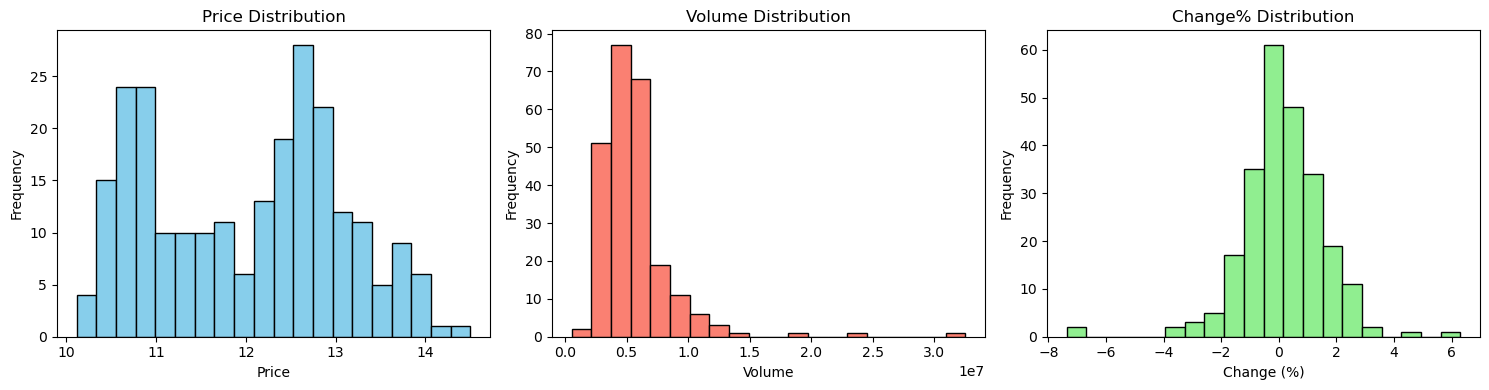

In [145]:
# visualize useful things in the dataframe such as price, volume and change%

# Convert columns to numeric if needed
df_scrambled['Price'] = pd.to_numeric(df_scrambled['Price'], errors='coerce')
df_scrambled['Volume'] = pd.to_numeric(df_scrambled['Volume'], errors='coerce')
df_scrambled['Change%'] = df_scrambled['Change%'].str.replace('%', '').astype(float)

plt.figure(figsize=(15, 4))

# Histogram: Price
plt.subplot(1, 3, 1)
plt.hist(df_scrambled['Price'], bins=20, color='skyblue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Histogram: Volume
plt.subplot(1, 3, 2)
plt.hist(df_scrambled['Volume'], bins=20, color='salmon', edgecolor='black')
plt.title('Volume Distribution')
plt.xlabel('Volume')
plt.ylabel('Frequency')

# Histogram: Change%
plt.subplot(1, 3, 3)
plt.hist(df_scrambled['Change%'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Change% Distribution')
plt.xlabel('Change (%)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()